# H5 Functionalities
Lets try to extract the data from H5 files. 

In [1]:
from ase import Atoms
from ase.build import molecule
from ase.units import Ha
from ase_dirac import DIRAC
import h5py
import numpy as np
from typing import Optional, Union
import matplotlib.pyplot as plt

In [2]:
molecule_label = "H2"
ase_molecule = molecule(molecule_label)

# **HAMILTONIAN
# .LVCORR
ase_molecule.calc = DIRAC(
    hamiltonian={".lvcorr": ""},
    wave_function={
        ".scf": "",
        "*scf": {".ergcnv": "1.E-8 1.E-6", ".maxitr": "35"},
    },
    molecule={"*basis": {".default": "dyall.3zp"}},
    label=molecule_label,
)
print(
    f"The Hartree-Fock energy of {molecule_label} is ",
    ase_molecule.get_potential_energy() / Ha,
    " Hartree.",
)

 starting DIRAC for molecule ./H2.xyz with input ./H2.inp
  creating archive file  H2.tgz
  archived working files: ['MOLECULE.XYZ', 'DIRAC.INP', 'AOPROPER', 'AOMOMAT', 'dirac.xml']
  exit           : normal
The Hartree-Fock energy of H2 is  -1.1335157158119715  Hartree.


In [3]:
def show(name, obj):
    if isinstance(obj, h5py.Group):
        print("Group:", name)
    elif isinstance(obj, h5py.Dataset):
        print("Dataset:", name, obj.shape)


f = h5py.File(f"{molecule_label}.h5", "r")
# f = h5py.File(f"H2.h5", "r")
f.visititems(show)
data_L = f["input/aobasis/1/"]
data_S = f["input/aobasis/2/"]
one_electron_ints = f["result/operators/ao_matrices"]
eigval = f["result/wavefunctions/scf/mobasis/eigenvalues"]
eigval[()]

Group: input
Group: input/aobasis
Group: input/aobasis/1
Dataset: input/aobasis/1/angular (1,)
Dataset: input/aobasis/1/aobasis_id (1,)
Dataset: input/aobasis/1/center (66,)
Dataset: input/aobasis/1/contractions (22,)
Dataset: input/aobasis/1/exponents (22,)
Dataset: input/aobasis/1/n_ao (1,)
Dataset: input/aobasis/1/n_cont (22,)
Dataset: input/aobasis/1/n_prim (22,)
Dataset: input/aobasis/1/n_shells (1,)
Dataset: input/aobasis/1/orbmom (22,)
Group: input/aobasis/2
Dataset: input/aobasis/2/angular (1,)
Dataset: input/aobasis/2/aobasis_id (1,)
Dataset: input/aobasis/2/center (78,)
Dataset: input/aobasis/2/contractions (26,)
Dataset: input/aobasis/2/exponents (26,)
Dataset: input/aobasis/2/n_ao (1,)
Dataset: input/aobasis/2/n_cont (26,)
Dataset: input/aobasis/2/n_prim (26,)
Dataset: input/aobasis/2/n_shells (1,)
Dataset: input/aobasis/2/orbmom (26,)
Dataset: input/dirac_inp (31,)
Group: input/molecule
Dataset: input/molecule/geometry (6,)
Dataset: input/molecule/n_atoms (1,)
Dataset: inp

array([-3.93553842e+04, -3.93548260e+04, -3.78899214e+04, -3.78891929e+04,
       -3.76441094e+04, -3.76432468e+04, -3.75850448e+04, -3.75840888e+04,
       -3.75671780e+04, -3.75671474e+04, -3.75640690e+04, -3.75633360e+04,
       -3.75622567e+04, -3.75622515e+04, -3.75621241e+04, -3.75614323e+04,
       -3.75614194e+04, -3.75609326e+04, -3.75594419e+04, -3.75589489e+04,
       -3.75589149e+04, -3.75588388e+04, -3.75587222e+04, -3.75587116e+04,
       -3.75585955e+04, -3.75584083e+04, -3.75582354e+04, -3.75581031e+04,
       -3.75578758e+04, -3.75578079e+04, -5.95782979e-01,  1.12258613e-01,
        1.40353627e-01,  3.61198964e-01,  5.42182717e-01,  5.42184997e-01,
        7.02915883e-01,  8.93858681e-01,  8.93860489e-01,  9.08964258e-01,
        9.20698409e-01,  1.41201819e+00,  2.33769525e+00,  2.75387216e+00,
        2.95539785e+00,  2.95546402e+00,  3.44136507e+00,  3.76943261e+00,
        3.76950884e+00,  5.04766439e+00,  7.48071001e+00,  7.49480276e+00,
        2.18551081e+01,  

## Large component
First we will take a look at the large component basis:

In [4]:
for key in data_L.keys():
    print(key, data_L[key][()])

angular [1]
aobasis_id [1]
center [ 0.          0.          0.69652092  0.          0.          0.69652092
  0.          0.          0.69652092  0.          0.          0.69652092
  0.          0.          0.69652092  0.          0.          0.69652092
  0.          0.          0.69652092  0.          0.          0.69652092
  0.          0.          0.69652092  0.          0.          0.69652092
  0.          0.          0.69652092  0.          0.         -0.69652092
  0.          0.         -0.69652092  0.          0.         -0.69652092
  0.          0.         -0.69652092  0.          0.         -0.69652092
  0.          0.         -0.69652092  0.          0.         -0.69652092
  0.          0.         -0.69652092  0.          0.         -0.69652092
  0.          0.         -0.69652092  0.          0.         -0.69652092]
contractions [1.17271151e+02 2.81716651e+01 9.26062084e+00 3.58683878e+00
 1.54473308e+00 7.17491960e-01 3.52672340e-01 1.80661752e-01
 9.39875374e-02 1.85673667e

Lets analyze each keyword-value pair: 

Keywords `centers`, `contractions`, and `exponents` are self-explanatory. Now,`n_ao` corresponds with the total number of Large component basis:

In [5]:
!grep 'Atoms and basis sets' F2.out -A 16

  Atoms and basis sets
  --------------------

  Number of atom types :    1
  Total number of atoms:    2

  label    atoms   charge   prim    cont     basis   
  ----------------------------------------------------------------------
  F           2       9      66      66      L  - [18s10p3d|18s10p3d]                                            
                            163     163      S  - [10s21p10d3f|10s21p10d3f]                                      
  ----------------------------------------------------------------------
                            132     132      L  - large components
                            326     326      S  - small components
  ----------------------------------------------------------------------
  total:      2      18     458     458

  Cartesian basis used.


The `orbmom` list contains the angular momentum definition of the basis: 

In [6]:
basisdict = {
    "s": 0,
    "p": 0,
    "d": 0,
    "f": 0,
    "g": 0,
    "h": 0,
}

amlist = ["s", "p", "d", "f", "g", "h"]

for val in data_L["orbmom"][()]:
    basisdict[amlist[val - 1]] += 1 / 2

basisstr = ""
for key in basisdict.keys():
    if basisdict[key] != 0:
        basisstr += f"{int(basisdict[key])}{key}"

basisstr_L = basisstr

print(f"The contracted LC basis function is: {basisstr}.")

total_basis = 0


def cartesian_projections(l: int) -> int:
    return (l + 1) * (l + 2) // 2


for key in basisdict.keys():
    if basisdict[key] != 0:
        total_basis += int(basisdict[key]) * cartesian_projections(amlist.index(key))

print(
    f"The LC basis functions are {total_basis} per atom, so {total_basis*2} in total as expected in the previous grep."
)

The contracted LC basis function is: 9s2p.
The LC basis functions are 15 per atom, so 30 in total as expected in the previous grep.


And for the small component:

In [7]:
basisdict = {
    "s": 0,
    "p": 0,
    "d": 0,
    "f": 0,
    "g": 0,
    "h": 0,
}

amlist = ["s", "p", "d", "f", "g", "h"]

for val in data_S["orbmom"][()]:
    basisdict[amlist[val - 1]] += 1 / 2

basisstr = ""
for key in basisdict.keys():
    if basisdict[key] != 0:
        basisstr += f"{int(basisdict[key])}{key}"

basisstr_S = basisstr

print(f"The contracted SC basis function is: {basisstr}.")

total_basis_S = 0

for key in basisdict.keys():
    if basisdict[key] != 0:
        total_basis_S += int(basisdict[key]) * cartesian_projections(amlist.index(key))

print(
    f"The SC basis functions are {total_basis_S} per atom, so {total_basis_S*2} in total as expected in the previous grep."
)

print(f"The total number of LC + SC basis are {2*(total_basis_S + total_basis)}.")

The contracted SC basis function is: 2s9p2d.
The SC basis functions are 41 per atom, so 82 in total as expected in the previous grep.
The total number of LC + SC basis are 112.


## Matrix elements
Let's take a look now at the one electron matrix elements in the `.h5` file:

In [8]:
one_electron_ints.keys()

for key in one_electron_ints.keys():
    print(key, one_electron_ints[key][()].shape, one_electron_ints[key][()].dtype)

BETAMAT FFFT (6328,) float64
MOLFIELDTFFT (6328,) float64
OVERLAP TFFT (6328,) float64
aobasis_dim (1,) int64


The dimension of the basis (LC + SC) is: 

In [9]:
one_electron_ints["aobasis_dim"][0]

np.int64(112)

Now, `BETAMAT FFFT`, `MOLFIELDTFFT`, and `OVERLAP TFFT` are one-dimensional arrays. Therefore, this means that we have to manipulate them to return to the typical two-dimensional form. 


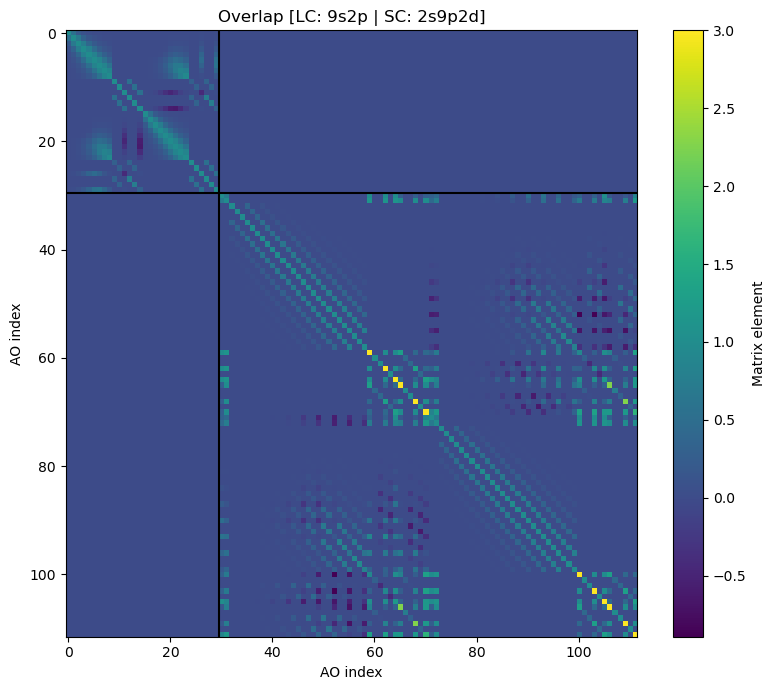

In [10]:
def retriangularize_and_conjugate(array, n_basis):
    M = np.zeros((n_basis, n_basis), dtype=array.dtype)
    k = 0
    for j in range(n_basis):
        for i in range(j + 1):
            M[i, j] = array[k]
            M[j, i] = np.conjugate(array[k])
            k += 1
    return M


def plot_packed_heatmap(
    array,
    n,
    LC_size: Optional[Union[int, None]] = None,
    title="Packed matrix heatmap",
    cmap="viridis",
):
    M = retriangularize_and_conjugate(array, n)
    Mplot = M.real if np.iscomplexobj(M) else M

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(Mplot, cmap=cmap, origin="upper", aspect="auto")
    fig.colorbar(im, ax=ax, label="Matrix element")

    ax.set_xlabel("AO index")
    ax.set_ylabel("AO index")
    ax.set_title(title)

    if LC_size is not None:
        ax.axvline(x=LC_size - 0.5, color="black", linewidth=1.5)
        ax.axhline(y=LC_size - 0.5, color="black", linewidth=1.5)

    plt.tight_layout()
    plt.show()

    return M


n = int(one_electron_ints["aobasis_dim"][0])
array = one_electron_ints["OVERLAP TFFT"][:]
M = plot_packed_heatmap(
    array,
    n,
    LC_size=data_L["n_ao"][0],
    title=f"Overlap [LC: {basisstr_L} | SC: {basisstr_S}]",
)

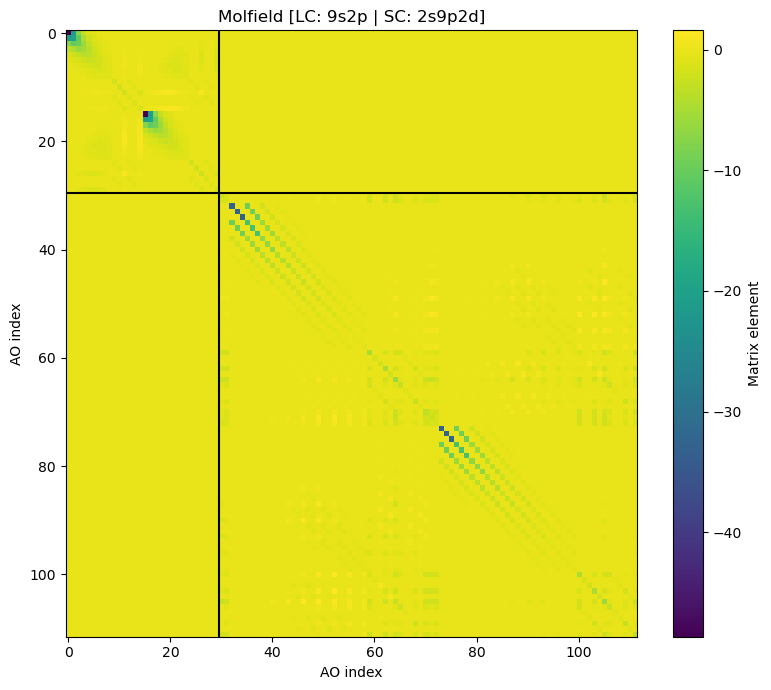

In [11]:
n = int(one_electron_ints['aobasis_dim'][0])
array = one_electron_ints['MOLFIELDTFFT'][:]
M = plot_packed_heatmap(array, n, LC_size=data_L['n_ao'][0], title=f"Molfield [LC: {basisstr_L} | SC: {basisstr_S}]")

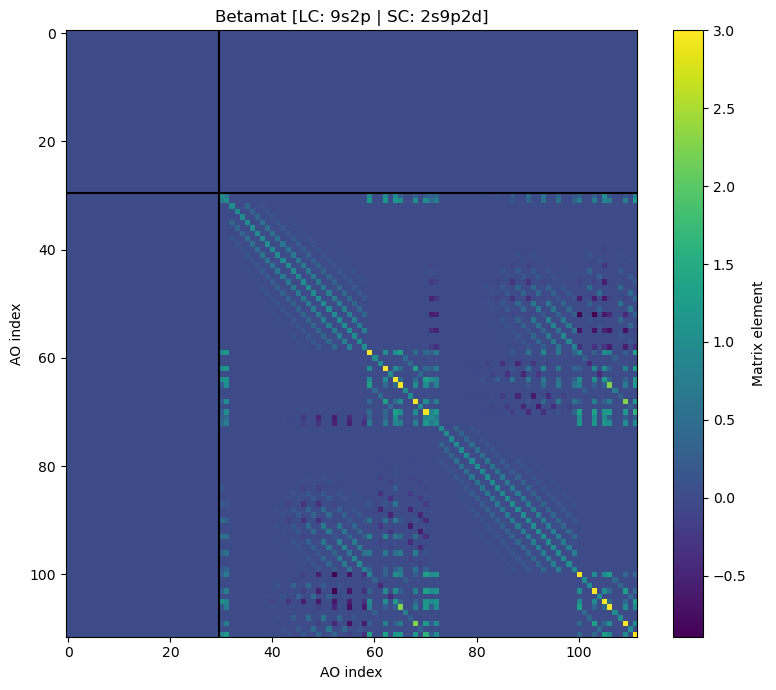

In [12]:
n = int(one_electron_ints['aobasis_dim'][0])
array = one_electron_ints['BETAMAT FFFT'][:]
M = plot_packed_heatmap(array, n, LC_size=data_L['n_ao'][0], title=f"Betamat [LC: {basisstr_L} | SC: {basisstr_S}]")